In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from datasets import Dataset

In [2]:
dataset = Dataset.from_parquet('/Users/kruthikasatish/Desktop/ai and text gagan/data/processed/cleaned_dataset.parquet')
df = dataset.to_pandas()
df["abstract_length"] = df["abstract"].apply(len)
df.head()

,id,year,title,abstract,category,period,abstract_length
0,0704.1274,2007,parametric learning and monte carlo optimization,"[uncovers, explores, close, relationship, mont...",cs.lg,2005-2009,102
1,0704.2010,2007,a study of structural properties on profiles hmms,"[motivation, profile, hidden, markov, model, p...",cs.ai,2005-2009,132
2,0704.3433,2007,bayesian approach to rough set,"[proposes, approach, training, rough, model, b...",cs.ai,2005-2009,70
3,0704.3515,2007,comparing robustness of pairwise and multiclas...,"[noise, corruption, variation, face, image, se...",cs.ai,2005-2009,52
4,0704.3708,2007,network statistics on early english syntax: st...,"[includes, reflection, role, network, english,...",cs.cl,2005-2009,96


In [3]:
print(df.shape)

(24806, 7)


In [4]:
print(df.iloc[0].abstract)

['uncovers' 'explores' 'close' 'relationship' 'monte' 'carlo'
 'optimization' 'parametrized' 'integral' 'mco' 'parametric' 'machine'
 'learning' 'blackbox' 'oracle' 'optimization' 'make' 'four'
 'contribution' 'prove' 'mco' 'mathematically' 'identical' 'broad' 'class'
 'problem' 'identity' 'potentially' 'provides' 'application' 'domain'
 'broadly' 'applicable' 'technique' 'mco' 'second' 'introduce' 'immediate'
 'sampling' 'version' 'probability' 'collective' 'algorithm' 'blackbox'
 'optimization' 'immediate' 'sampling' 'transforms' 'original' 'mco'
 'accordingly' 'combining' 'contribution' 'apply' 'technique' 'third'
 'contribution' 'validate' 'improving' 'demonstrating' 'cross'
 'validation' 'bagging' 'improve' 'immediate' 'sampling' 'finally'
 'conventional' 'mco' 'procedure' 'ignore' 'relationship' 'sample' 'point'
 'location' 'associated' 'value' 'integrand' 'value' 'integrand'
 'location' 'considered' 'demonstrate' 'exploit' 'sample' 'location'
 'information' 'technique' 'example'

In [5]:
df["text_abstract"] = df["abstract"].apply(lambda x: " ".join(x))

In [6]:
df.head()

,id,year,title,abstract,category,period,abstract_length,text_abstract
0,0704.1274,2007,parametric learning and monte carlo optimization,"[uncovers, explores, close, relationship, mont...",cs.lg,2005-2009,102,uncovers explores close relationship monte car...
1,0704.2010,2007,a study of structural properties on profiles hmms,"[motivation, profile, hidden, markov, model, p...",cs.ai,2005-2009,132,motivation profile hidden markov model phmms p...
2,0704.3433,2007,bayesian approach to rough set,"[proposes, approach, training, rough, model, b...",cs.ai,2005-2009,70,proposes approach training rough model bayesia...
3,0704.3515,2007,comparing robustness of pairwise and multiclas...,"[noise, corruption, variation, face, image, se...",cs.ai,2005-2009,52,noise corruption variation face image seriousl...
4,0704.3708,2007,network statistics on early english syntax: st...,"[includes, reflection, role, network, english,...",cs.cl,2005-2009,96,includes reflection role network english langu...


In [7]:
theory_words = [ 'theory' , 'hypothesis', 'framework', 'approach', 'theorem']
application_words = ['application', 'dataset', 'experiment', 'implement']

In [8]:
# theory_words = [
#     "theory", "framework", "model", "method", "approach",
#     "formal", "analysis", "derive", "proof", "theorem",
#     "assumption", "hypothesis", "concept", "algorithm"
# ]

# application_words = [
#     "application", "real", "dataset", "experiment", "clinical",
#     "evaluation", "implementation", "performance", "case",
#     "deployment", "system", "study", "results", "benchmark"
# ]

In [ ]:
# Comparative analysis of the keyword strategies revealed that inclusive datasets obscured the underlying trends. 
# Because both theoretical and experimental approaches are evolving in parallel, focusing on the five most critical 
# keywords provides the necessary clarity to accurately observe and conclude their shared developmental trajectory.

In [9]:
#Approach 1
#Raw Term Frequency: proportion of papers containing each term per year
def raw_term_frequency (df, terms):
    res= []
    for year, group in df.groupby("year"):
        total_tok = group["abstract_length"].sum()
        count = group["text_abstract"].apply(lambda x: sum(x.count(term) for term in terms)).sum()
        score = count/total_tok
        res.append({"year": year,
                   "proportion":score})
    return pd.DataFrame(res).sort_values("year")

In [10]:
raw_theory = raw_term_frequency(df, theory_words)
raw_application = raw_term_frequency(df, application_words)

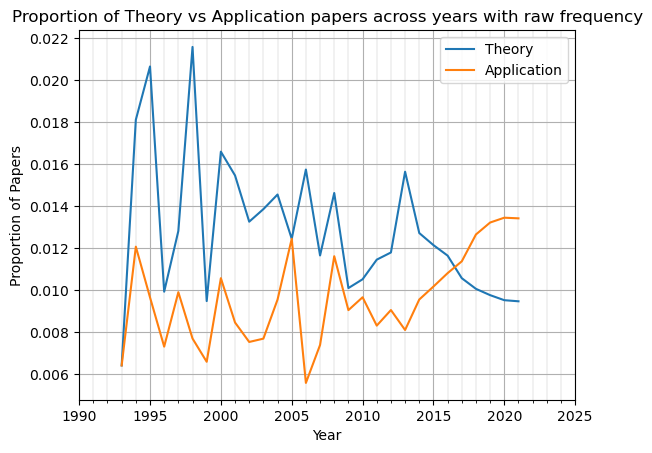

In [11]:
plt.plot(raw_theory["year"], raw_theory["proportion"],label="Theory")
plt.plot(raw_application["year"], raw_application["proportion"],label="Application")
plt.legend()
plt.xticks(range(1990,2026,5))
plt.gca().set_xticks(range(1990,2026),minor=True)
plt.xlabel("Year")
plt.ylabel("Proportion of Papers")
plt.title("Proportion of Theory vs Application papers across years with raw frequency")
plt.grid(which='major')
plt.grid(which='minor', linewidth=0.25)
plt.show()        

In [12]:
#The application language seems to take over the theory language around 2014 with raw term frequencies which are normalised by number of tokens 

In [13]:
#Approach 2 
#TF-IDF weighted scores per period, highlighting what is distinctive per era rather than merely frequent
vectorizer = TfidfVectorizer(vocabulary = theory_words + application_words, lowercase = False)
tfidf = vectorizer.fit_transform(df["text_abstract"])
tfidf_df = pd.DataFrame(tfidf.toarray(),
                       columns = vectorizer.get_feature_names_out())

tfidf_df.head()

,theory,hypothesis,framework,approach,theorem,application,dataset,experiment,implement
0,0.0,0.0,0.000000,0.00000,0.0,1.0,0.0,0.000000,0.0
1,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,1.000000,0.0
2,0.0,0.0,0.567316,0.82350,0.0,0.0,0.0,0.000000,0.0
3,0.0,0.0,0.000000,0.85665,0.0,0.0,0.0,0.515899,0.0
4,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.0


In [14]:
tfidf_df["year"]= df["year"].values
tfidf_df["period"] = df["period"].values

In [15]:
tfidf_df.head()

,theory,hypothesis,framework,approach,theorem,application,dataset,experiment,implement,year,period
0,0.0,0.0,0.000000,0.00000,0.0,1.0,0.0,0.000000,0.0,2007,2005-2009
1,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,1.000000,0.0,2007,2005-2009
2,0.0,0.0,0.567316,0.82350,0.0,0.0,0.0,0.000000,0.0,2007,2005-2009
3,0.0,0.0,0.000000,0.85665,0.0,0.0,0.0,0.515899,0.0,2007,2005-2009
4,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.0,2007,2005-2009


In [16]:
tfidf_year = (tfidf_df.groupby("year").mean(numeric_only=True).reset_index())

In [17]:
tfidf_year["theory_score"] = tfidf_year[theory_words].mean(axis=1)
tfidf_year["application_score"] = tfidf_year[application_words].mean(axis=1)

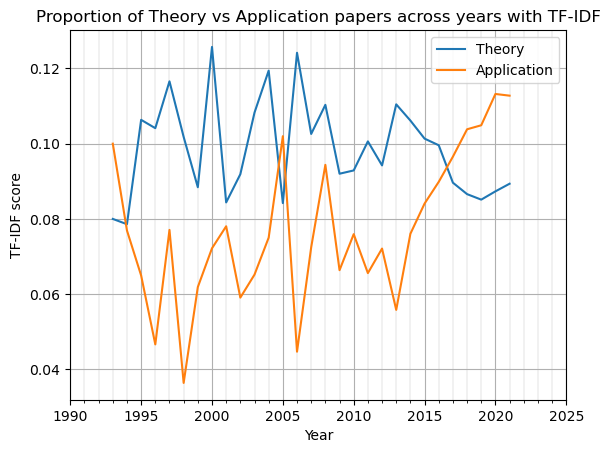

In [18]:
plt.plot(tfidf_year["year"], tfidf_year["theory_score"],label="Theory")
plt.plot(tfidf_year["year"], tfidf_year["application_score"],label="Application")
plt.legend()
plt.xticks(range(1990,2026,5))
plt.gca().set_xticks(range(1990,2026),minor=True)
plt.xlabel("Year")
plt.ylabel("TF-IDF score")
plt.title("Proportion of Theory vs Application papers across years with TF-IDF")
plt.grid(which='major')
plt.grid(which='minor', linewidth=0.25)
plt.show()

In [19]:
#The application language seems to take over the theory language around 2015 according to TF-IDF